# EDA

Load the three project parquets and produce a per-series mini-table
(inception date, n_obs, % missing, friendly name, source ticker) for
the EDA report. Outputs `data/quality/data_inventory.{csv,md}`.

In [1]:
# === Step 1: Data inventory ===

import numpy as np
import pandas as pd
from pathlib import Path

pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 180)

# Detect repo root
cwd = Path.cwd()

if cwd.name == "notebooks":
    ROOT = cwd.parent
else:
    ROOT = cwd

DATA_DIR = ROOT / "data" / "processed"

PRICES_PATH  = DATA_DIR / "prices.parquet"
RETURNS_PATH = DATA_DIR / "returns.parquet"
EXOG_PATH    = DATA_DIR / "exogenous_features.parquet"
SUMMARY_PATH = DATA_DIR / "summary.csv"

In [3]:
prices  = pd.read_parquet(PRICES_PATH)
exog = pd.read_parquet(EXOG_PATH)
returns = pd.read_parquet(RETURNS_PATH)

# Index sanity
for name, df in [("prices", prices), ("exog", exog), ("returns", returns)]:
    if not isinstance(df.index, pd.DatetimeIndex):
        print(f"WARNING: {name} index is {type(df.index).__name__}, not DatetimeIndex")

def file_overview(name, df):
    return {
        "file":       name,
        "n_rows":     len(df),
        "n_cols":     df.shape[1],
        "first_date": df.index.min().strftime("%Y-%m-%d"),
        "last_date":  df.index.max().strftime("%Y-%m-%d"),
        "n_days":     (df.index.max() - df.index.min()).days,
    }

overview = pd.DataFrame([
    file_overview("prices",  prices),
    file_overview("exog",    exog),
    file_overview("returns", returns),
])
print(overview.to_string(index=False))

   file  n_rows  n_cols first_date  last_date  n_days
 prices    2706      15 2016-01-01 2026-05-15    3787
   exog    2706       7 2016-01-01 2026-05-15    3787
returns    2706      15 2016-01-01 2026-05-15    3787


In [7]:
assert prices.shape[1] == 15, f"prices: expected 15 cols, got {prices.shape[1]}"
assert exog.shape[1] == 7, f"exog: expected 7 cols, got {exog.shape[1]}"
print("Column counts OK (15 prices + 7 exog)\n")

# Print actual column names so you know what to populate in SERIES_INFO
print("prices columns:")
print(list(prices.columns))
print("\nexog columns:")
print(list(exog.columns))

Column counts OK (15 prices + 7 exog)

prices columns:
['WTI', 'Brent', 'RBOB', 'HO', 'HH_NG', 'TTF', 'USO', 'UNG', 'UGA', 'AUDUSD', 'DXY', 'BrentWTI_spread', 'USGCJet', 'JetBrent_crack', 'HOBrent_crack']

exog columns:
['RF', 'TNX', 'OilVol', 'VIX', 'CrudeStocks', 'DistStocks', 'RefineryUtil']


In [17]:
# Update the macro block to match the columns printed above.
SERIES_INFO = {
    # ---- prices: outrights (positive series) ----
    "Brent":   {"name": "Brent crude (front-month)",      "category": "crude"},
    "WTI":     {"name": "WTI crude (front-month)",        "category": "crude"},
    "USGCJet": {"name": "US Gulf Coast jet fuel",         "category": "product"},
    "HO":      {"name": "NY Harbor heating oil",          "category": "product"},
    "RBOB":    {"name": "RBOB gasoline",                  "category": "product"},
    "HH_NG":   {"name": "Henry Hub natural gas",          "category": "gas"},
    "TTF":     {"name": "Dutch TTF natural gas",          "category": "gas"},
    # ---- FX / index ----
    "AUDUSD":  {"name": "AUD/USD exchange rate",          "category": "fx"},
    "DXY":     {"name": "US Dollar Index",                "category": "fx"},
    # ---- ETFs ----
    "USO":     {"name": "United States Oil Fund",         "category": "etf"},
    "UNG":     {"name": "United States Natural Gas Fund", "category": "etf"},
    "UGA":     {"name": "United States Gasoline Fund",    "category": "etf"},
    # ---- derived spreads / cracks ----
    "BrentWTI_spread": {"name": "Brent–WTI spread",         "category": "spread"},
    "HOBrent_crack":   {"name": "Heating oil–Brent crack",  "category": "crack"},
    "JetBrent_crack":  {"name": "Jet fuel–Brent crack",     "category": "crack"},
    # ---- exogenous: physical fundamentals (EIA weekly, forward-filled to daily) ----
    "CrudeStocks":   {"name": "US crude oil inventories (EIA)",     "category": "fundamental"},
    "DistStocks":    {"name": "US distillate inventories (EIA)",    "category": "fundamental"},
    "RefineryUtil":  {"name": "US refinery utilization rate (EIA)", "category": "fundamental"},
    # ---- exogenous: volatility indices ----
    "OilVol": {"name": "CBOE crude oil volatility index (^OVX)",          "category": "vol"},
    "VIX":    {"name": "CBOE volatility index (^VIX)",                    "category": "vol"},
    # ---- exogenous: rates ----
    "TNX":    {"name": "10-year Treasury yield (CBOE ^TNX, % p.a. ×10)",  "category": "rates"},
    "RF":     {"name": "3-month T-bill yield (CBOE ^IRX, % p.a.)",       "category": "rates"},
}

# Coverage check
needed   = set(prices.columns) | set(exog.columns)
covered  = set(SERIES_INFO.keys())
missing  = needed - covered
unused   = covered - needed
if missing:
    print(f"Add SERIES_INFO entries for: {sorted(missing)}")
if unused:
    print(f"SERIES_INFO has entries that aren't in the data: {sorted(unused)}")
if not missing and not unused:
    print("SERIES_INFO covers all 22 columns")

SERIES_INFO covers all 22 columns


In [18]:
def inventory_row(ticker, s, info):
    """One row per series: inception, last obs, n_obs, % missing within window."""
    valid = s.dropna()
    WEEKLY_SERIES = {"CrudeStocks", "DistStocks", "RefineryUtil"}
    if len(valid):
        inception = valid.index.min()
        last_obs  = valid.index.max()
        # % missing measured from inception → last_obs, so late-starting series
        # aren't unfairly penalised for not having pre-history.
        in_window = s.loc[inception:last_obs]
        pct_miss  = 100 * in_window.isna().mean()
    else:
        inception, last_obs, pct_miss = pd.NaT, pd.NaT, np.nan

    meta = info.get(ticker, {})
    return {
        "ticker":        ticker,
        "friendly_name": meta.get("name", "(missing — add to SERIES_INFO)"),
        "category":      meta.get("category", "?"),
        "frequency": "weekly→daily ffill" if ticker in WEEKLY_SERIES else "daily",
        "inception":     inception.strftime("%Y-%m-%d") if pd.notna(inception) else "",
        "last_obs":      last_obs.strftime("%Y-%m-%d")  if pd.notna(last_obs)  else "",
        "n_obs":         int(len(valid)),
        "pct_missing":   round(pct_miss, 2),
    }

rows = []
for col in prices.columns:
    rows.append(inventory_row(col, prices[col], SERIES_INFO))
for col in exog.columns:
    rows.append(inventory_row(col, exog[col], SERIES_INFO))

inventory = (pd.DataFrame(rows)
               .sort_values(["category", "ticker"])
               .reset_index(drop=True))
inventory

,ticker,friendly_name,category,frequency,inception,last_obs,n_obs,pct_missing
0,HOBrent_crack,Heating oil–Brent crack,crack,daily,2016-01-04,2026-05-15,2705,0.0
1,JetBrent_crack,Jet fuel–Brent crack,crack,daily,2016-01-04,2026-05-15,2705,0.0
2,Brent,Brent crude (front-month),crude,daily,2016-01-04,2026-05-15,2705,0.0
3,WTI,WTI crude (front-month),crude,daily,2016-01-04,2026-05-15,2705,0.0
4,UGA,United States Gasoline Fund,etf,daily,2016-01-04,2026-05-15,2705,0.0
5,UNG,United States Natural Gas Fund,etf,daily,2016-01-04,2026-05-15,2705,0.0
6,USO,United States Oil Fund,etf,daily,2016-01-04,2026-05-15,2705,0.0
7,CrudeStocks,US crude oil inventories (EIA),fundamental,weekly→daily ffill,2016-01-01,2026-05-15,2706,0.0
8,DistStocks,US distillate inventories (EIA),fundamental,weekly→daily ffill,2016-01-01,2026-05-15,2706,0.0
9,RefineryUtil,US refinery utilization rate (EIA),fundamental,weekly→daily ffill,2016-01-01,2026-05-15,2706,0.0


In [19]:
summary = pd.read_csv(SUMMARY_PATH)
inventory = inventory.merge(
    summary[["name", "yahoo_symbol"]],
    left_on="ticker", right_on="name", how="left",
).drop(columns="name")

# Derived series + EIA fundamentals aren't in summary.csv — mark explicitly
inventory["yahoo_symbol"] = inventory["yahoo_symbol"].fillna("(derived/EIA)")
inventory

,ticker,friendly_name,category,frequency,inception,last_obs,n_obs,pct_missing,yahoo_symbol
0,HOBrent_crack,Heating oil–Brent crack,crack,daily,2016-01-04,2026-05-15,2705,0.0,(derived/EIA)
1,JetBrent_crack,Jet fuel–Brent crack,crack,daily,2016-01-04,2026-05-15,2705,0.0,(derived/EIA)
2,Brent,Brent crude (front-month),crude,daily,2016-01-04,2026-05-15,2705,0.0,BZ=F
3,WTI,WTI crude (front-month),crude,daily,2016-01-04,2026-05-15,2705,0.0,CL=F
4,UGA,United States Gasoline Fund,etf,daily,2016-01-04,2026-05-15,2705,0.0,UGA
5,UNG,United States Natural Gas Fund,etf,daily,2016-01-04,2026-05-15,2705,0.0,UNG
6,USO,United States Oil Fund,etf,daily,2016-01-04,2026-05-15,2705,0.0,USO
7,CrudeStocks,US crude oil inventories (EIA),fundamental,weekly→daily ffill,2016-01-01,2026-05-15,2706,0.0,(derived/EIA)
8,DistStocks,US distillate inventories (EIA),fundamental,weekly→daily ffill,2016-01-01,2026-05-15,2706,0.0,(derived/EIA)
9,RefineryUtil,US refinery utilization rate (EIA),fundamental,weekly→daily ffill,2016-01-01,2026-05-15,2706,0.0,(derived/EIA)


In [20]:
# Detect repo root
cwd = Path.cwd()

if cwd.name == "notebooks":
    ROOT = cwd.parent
else:
    ROOT = cwd

# Output folder
OUT_DIR = ROOT / "data" / "quality"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Save files
inventory.to_csv(OUT_DIR / "data_inventory.csv", index=False)
inventory.to_markdown(OUT_DIR / "data_inventory.md", index=False)

print(f"Wrote {OUT_DIR / 'data_inventory.csv'}")
print(f"Wrote {OUT_DIR / 'data_inventory.md'}")

Wrote c:\Users\Bryant\Documents\USYD\Year 3\sem 2\QBUS3850\group assignment\repo_v2\Time-Series-Forecasting\data\quality\data_inventory.csv
Wrote c:\Users\Bryant\Documents\USYD\Year 3\sem 2\QBUS3850\group assignment\repo_v2\Time-Series-Forecasting\data\quality\data_inventory.md


## Bucket 1 Stylized facts (10 tradeable prices)

```text
6 futures: WTI, Brent, RBOB, HO, HH_NG, TTF
3 ETFs:    USO, UNG, UGA
1 EIA:     USGCJet
─────────
10 total
```

In [22]:
# === Step 2: Bucket 1 stylized facts (10 tradable energy prices) ===

import sys
import json
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sys.path.insert(0, str(ROOT))
from utils.eda import adf_test, kpss_test, arch_lm_test, stl_decompose
from utils.plot import overlay_breaks, SHORT_BREAK_LABELS

QUALITY_DIR = ROOT / "data" / "quality"
FIGURES_DIR = ROOT / "figures" / "02_eda"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Bucket 1: forecast targets that take the price-level model stack
# (ETS, ARIMA, ARIMAX, SARIMA, Auto-ARIMA, Kalman, GARCH for intervals)
TRADABLE = [
    "Brent", "WTI", "HO", "RBOB", "HH_NG", "TTF",   # 6 futures
    "USO", "UNG", "UGA",                            # 3 ETFs
    "USGCJet",                                      # 1 EIA daily assessment
]
assert all(c in prices.columns  for c in TRADABLE), \
    f"Missing in prices.parquet: {[c for c in TRADABLE if c not in prices.columns]}"
assert all(c in returns.columns for c in TRADABLE), \
    f"Missing in returns.parquet: {[c for c in TRADABLE if c not in returns.columns]}"

breaks = pd.read_csv(QUALITY_DIR / "structural_breaks.csv",
                     parse_dates=["start_date", "end_date"])

print(f"Bucket 1 TRADABLE: {TRADABLE}")

Bucket 1 TRADABLE: ['Brent', 'WTI', 'HO', 'RBOB', 'HH_NG', 'TTF', 'USO', 'UNG', 'UGA', 'USGCJet']


### Prices with structural breaks

visual context, regime identification.

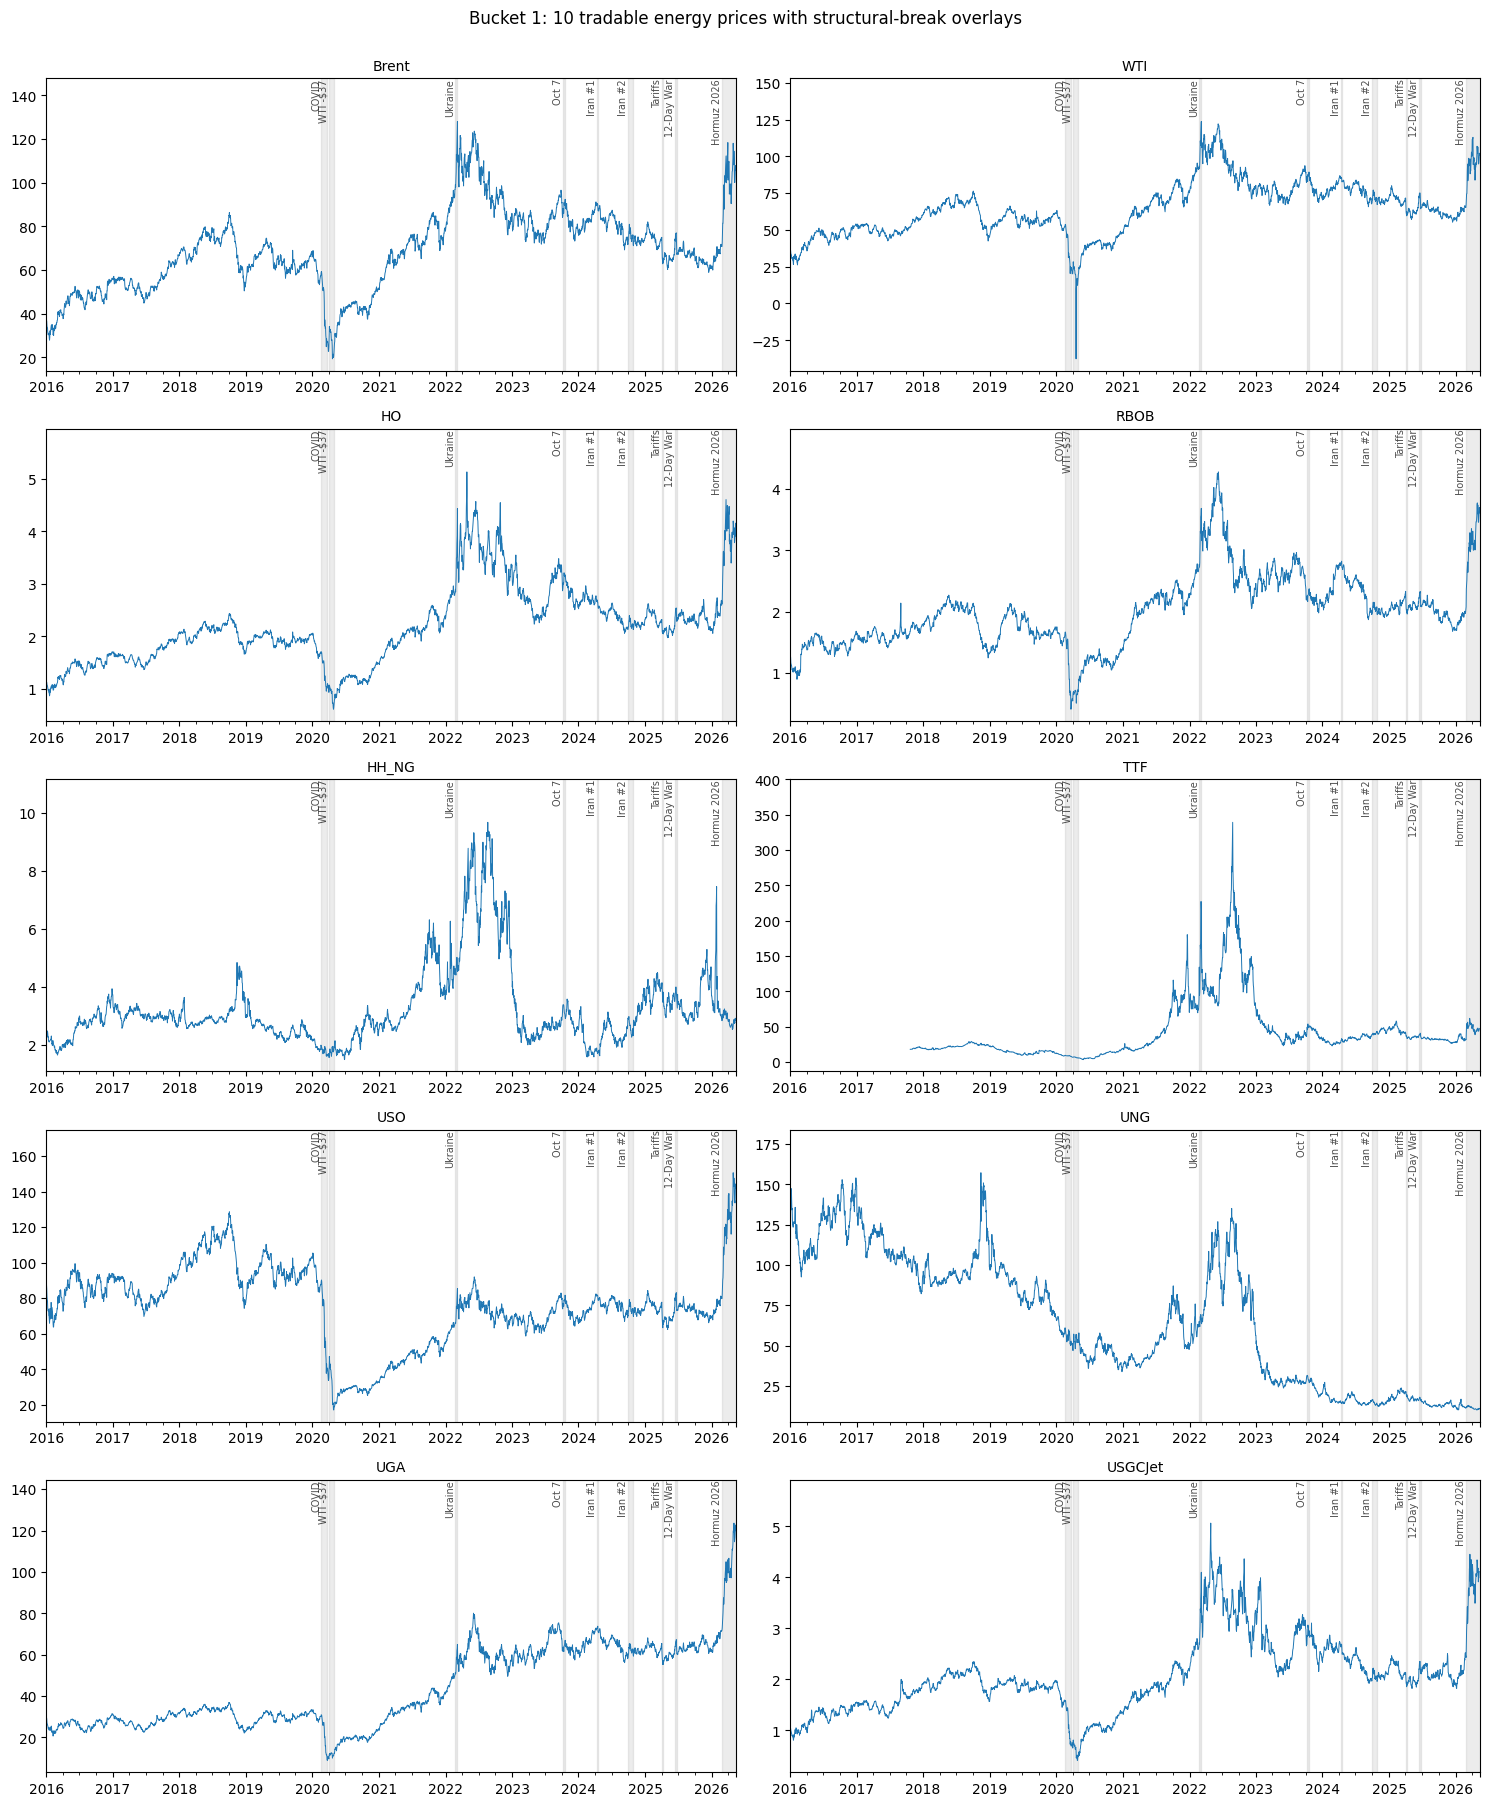

In [23]:
fig, axes = plt.subplots(5, 2, figsize=(15, 18))
for ax, col in zip(axes.flat, TRADABLE):
    prices[col].plot(ax=ax, linewidth=0.7)
    overlay_breaks(ax, breaks, short_labels=SHORT_BREAK_LABELS)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
plt.suptitle("Bucket 1: 10 tradable energy prices with structural-break overlays",
             y=1.001, fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "step2_01_prices_with_breaks.png")
plt.show()

### Log-returns small multiples

shows volatility clustering visually before the test confirms it.

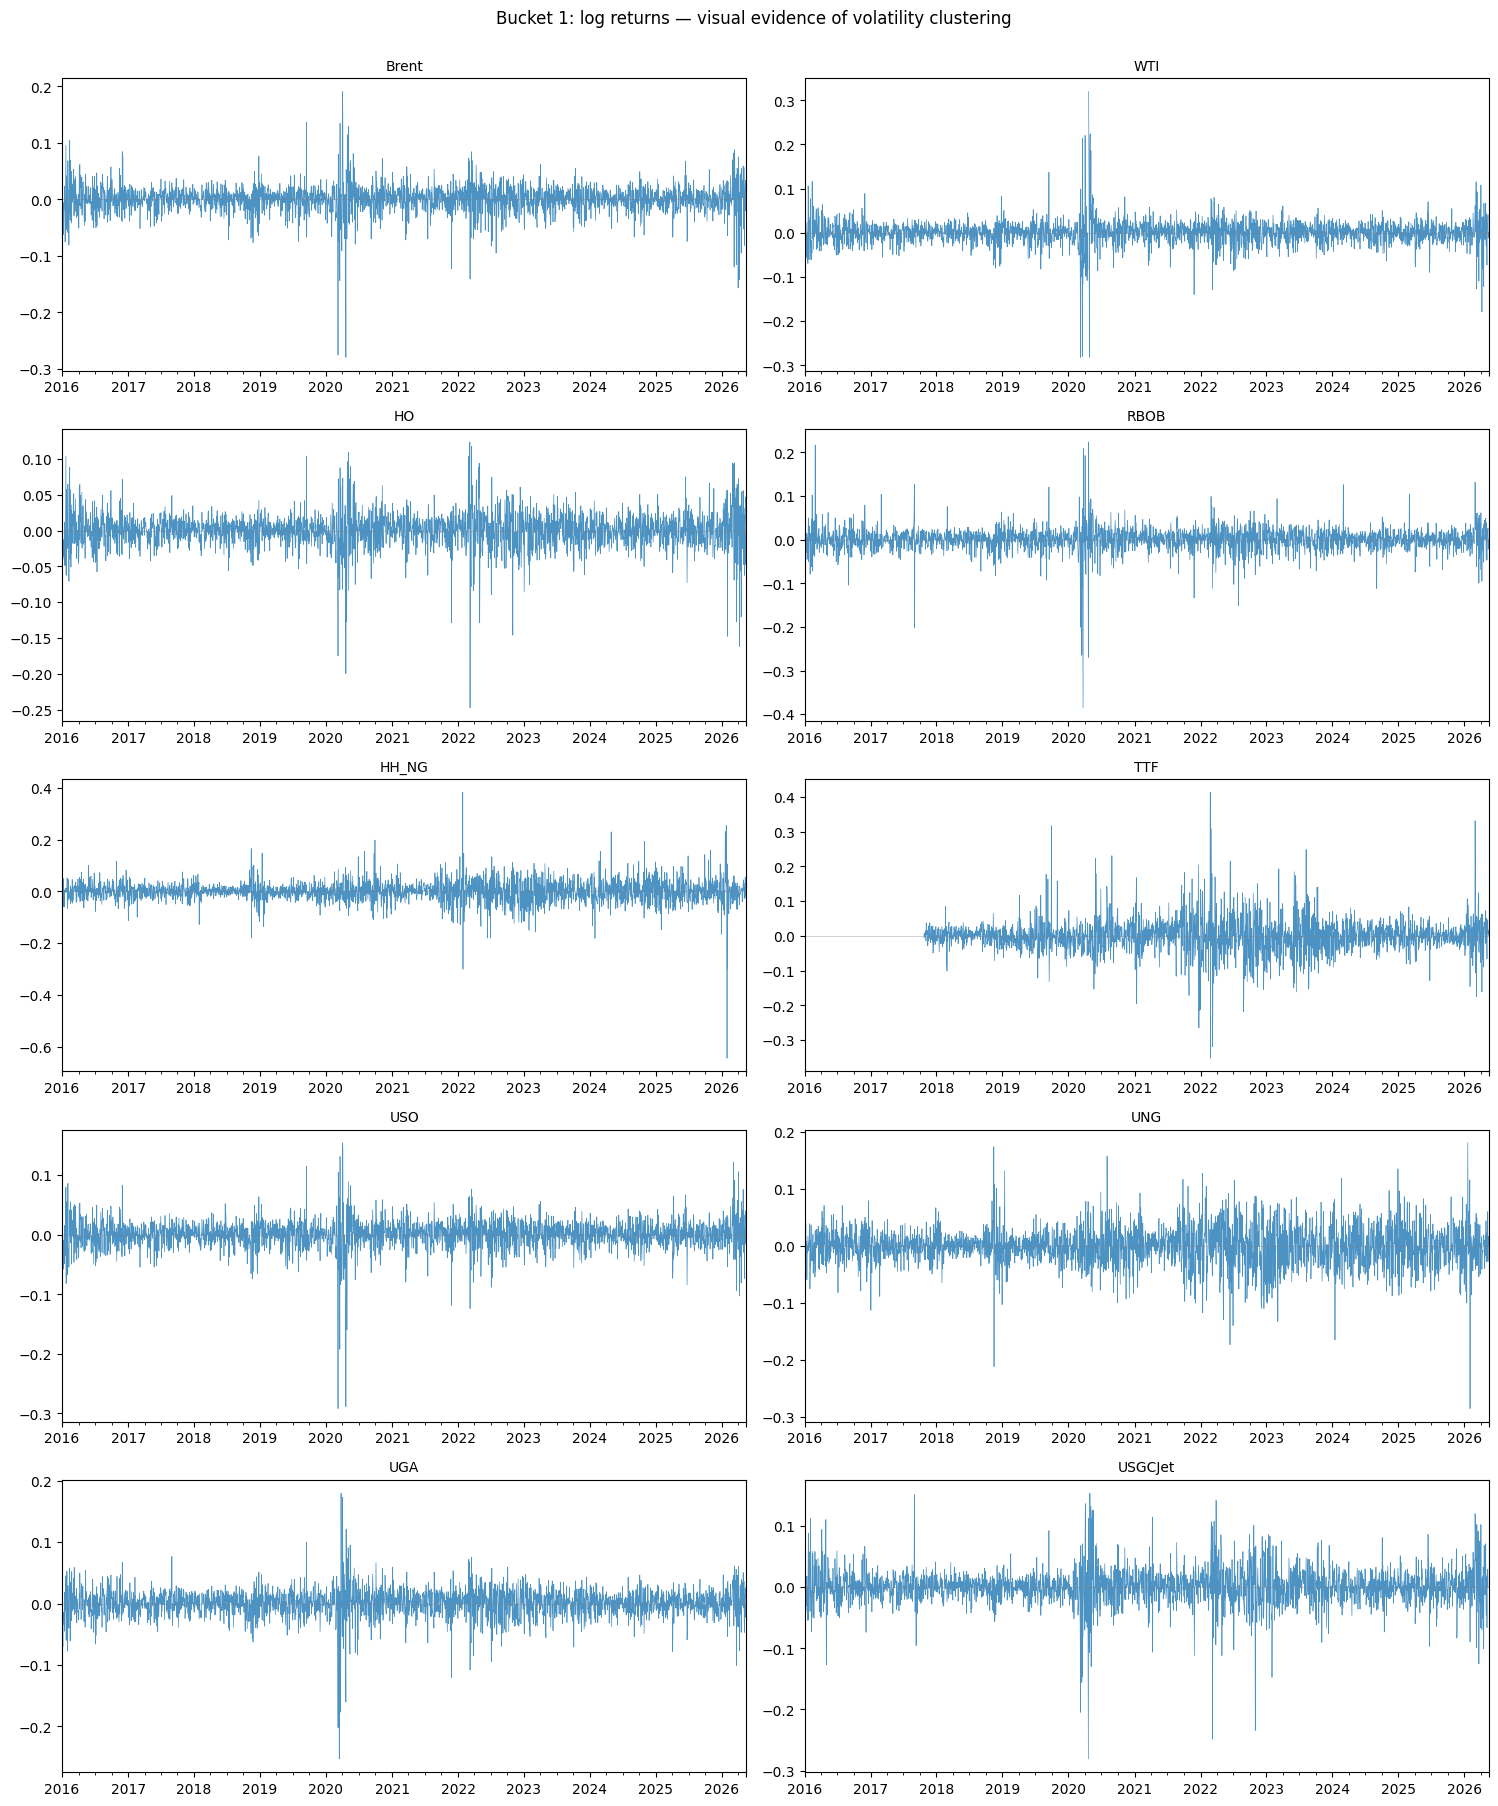

In [24]:
fig, axes = plt.subplots(5, 2, figsize=(15, 18))
for ax, col in zip(axes.flat, TRADABLE):
    returns[col].plot(ax=ax, linewidth=0.5, alpha=0.8)
    ax.axhline(0, color="grey", linewidth=0.5, alpha=0.5)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
plt.suptitle("Bucket 1: log returns — visual evidence of volatility clustering",
             y=1.001, fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "step2_02_returns_grid.png")
plt.show()

### ACF/PACF on returns (40 lags)

evidence for ARIMA-order suitability. If returns show no autocorrelation, that's a finding, as a pure RW is the benchmark to beat.

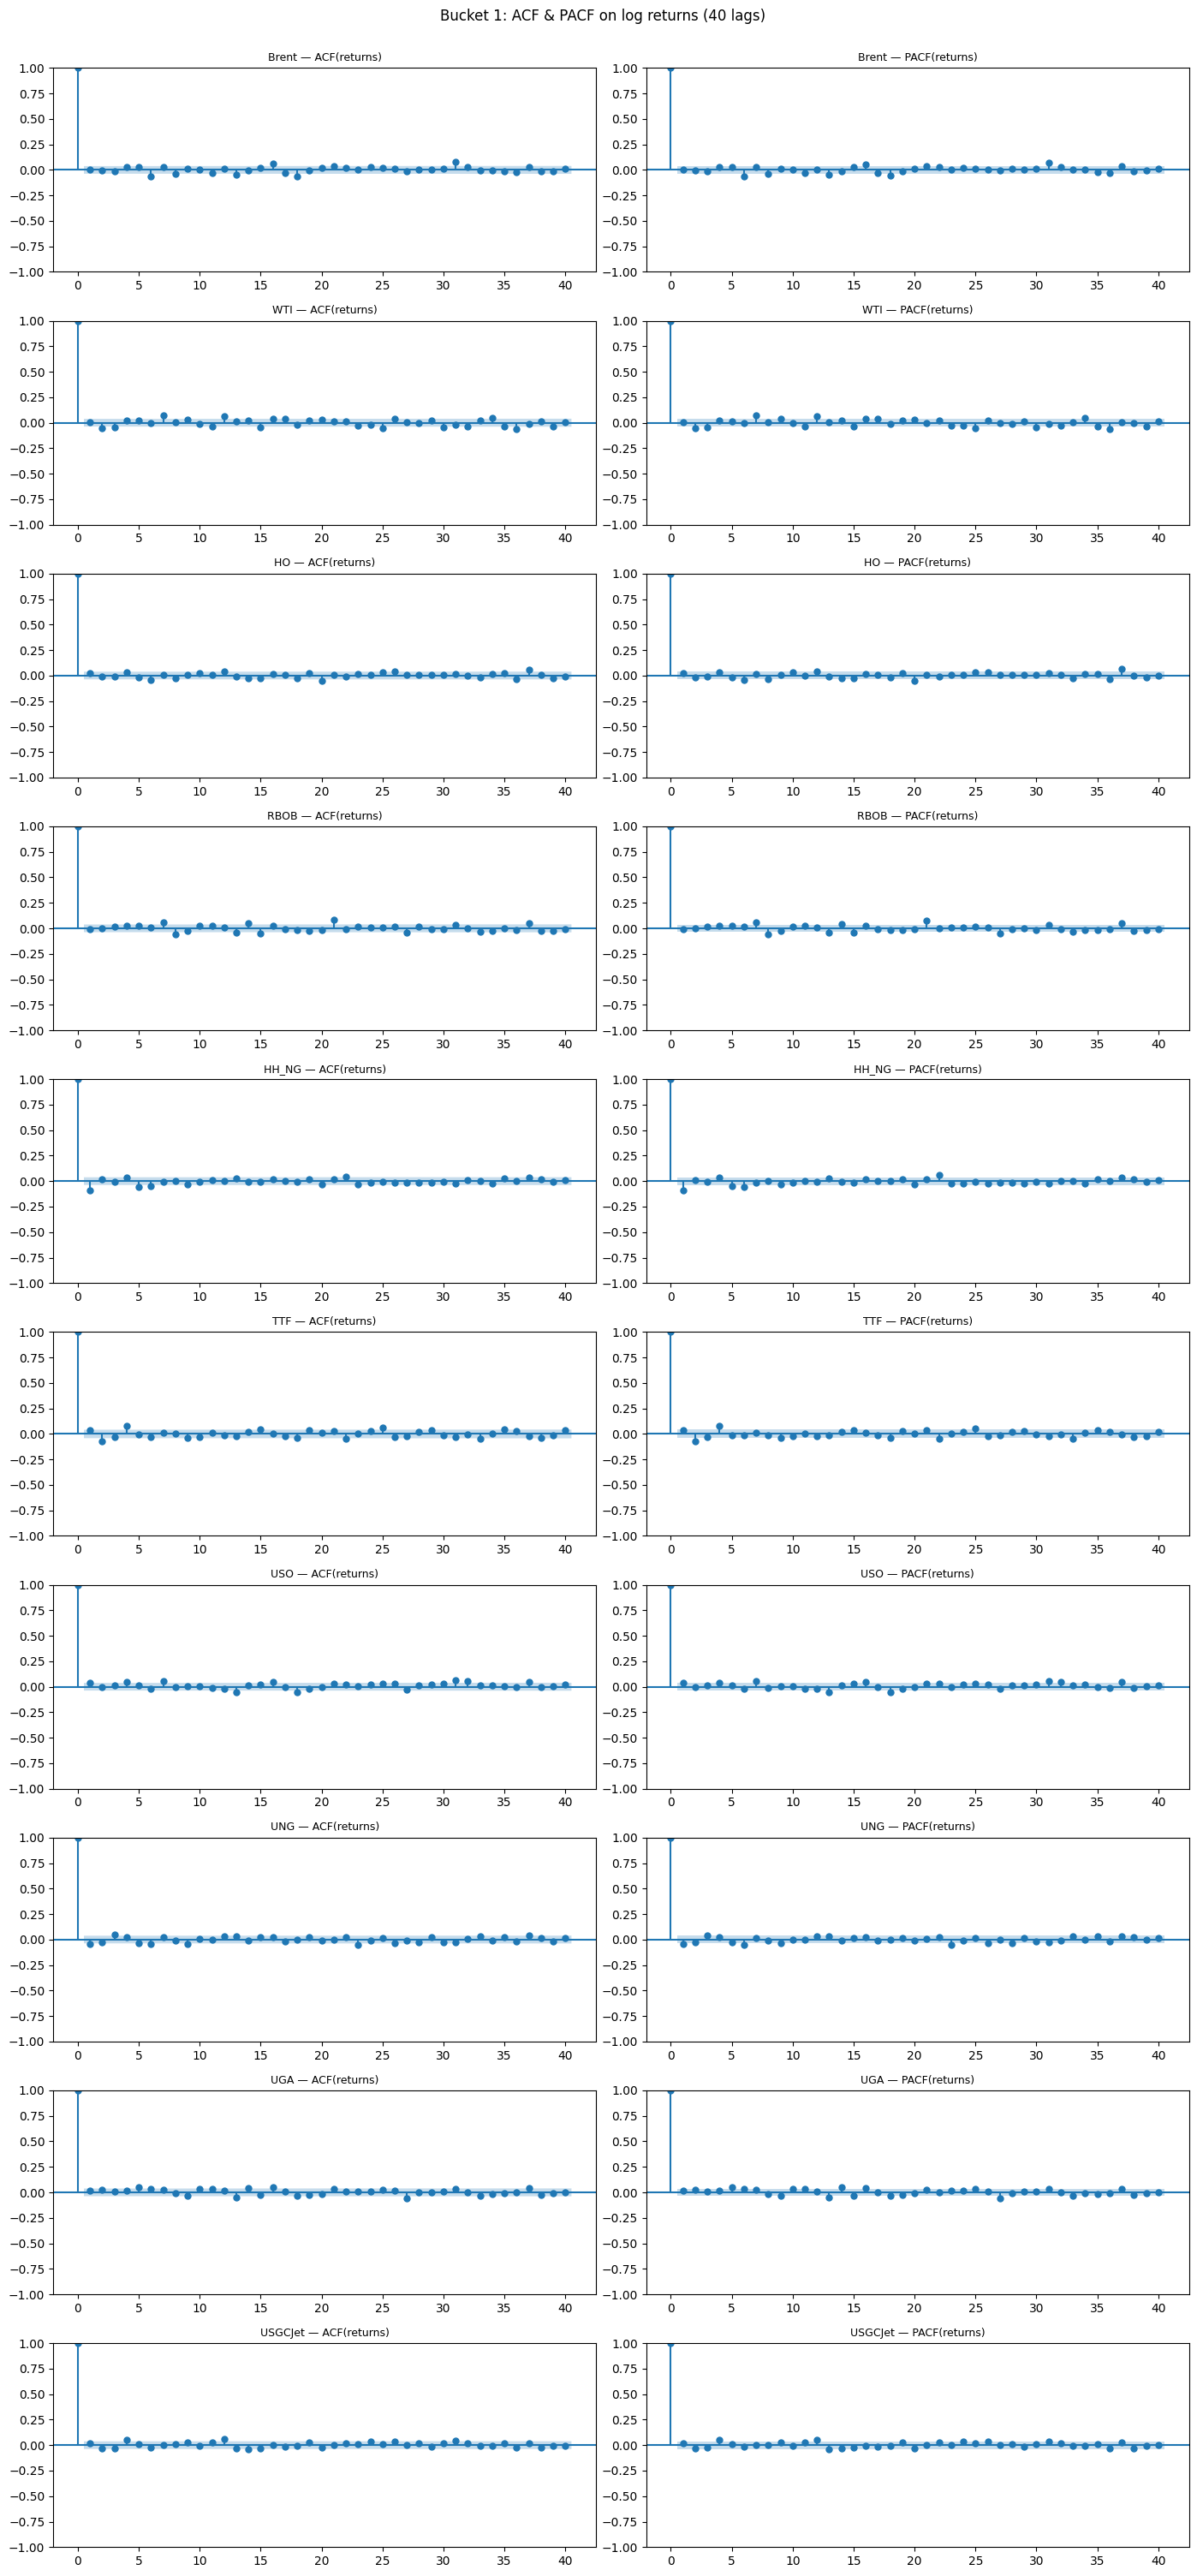

In [25]:
fig, axes = plt.subplots(10, 2, figsize=(14, 30))
for i, col in enumerate(TRADABLE):
    r = returns[col].dropna()
    plot_acf(r, lags=40, ax=axes[i, 0])
    axes[i, 0].set_title(f"{col} — ACF(returns)", fontsize=9)
    plot_pacf(r, lags=40, ax=axes[i, 1], method="ywm")
    axes[i, 1].set_title(f"{col} — PACF(returns)", fontsize=9)
plt.suptitle("Bucket 1: ACF & PACF on log returns (40 lags)",
             y=1.001, fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "step2_03_acf_pacf_returns.png")
plt.show()

### Squared-return ACF

volatility-clustering picture. Persistent positive ACF on r² is what motivates **GARCH** for prediction intervals.

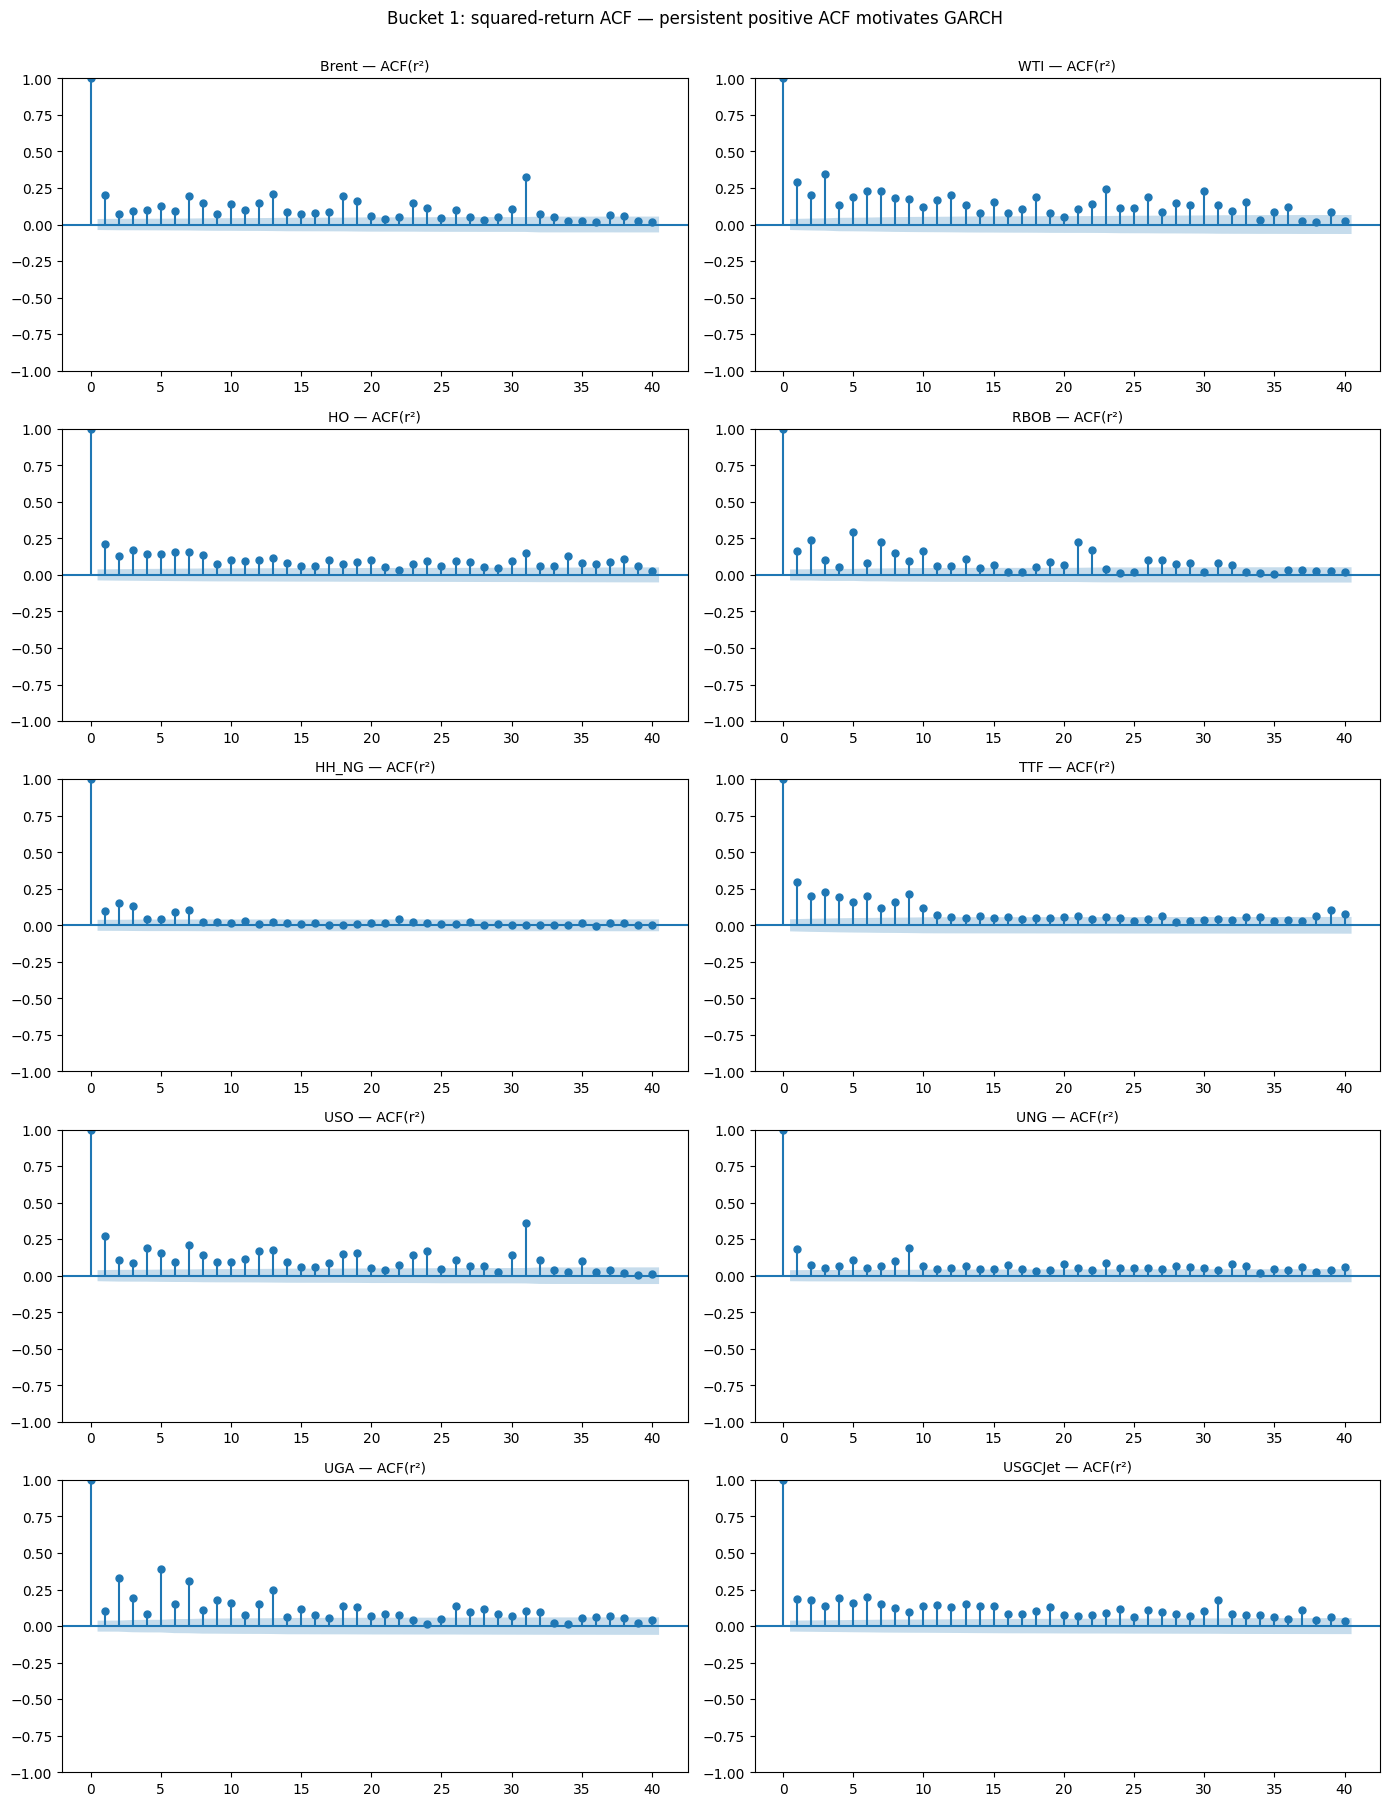

In [26]:
fig, axes = plt.subplots(5, 2, figsize=(14, 18))
for ax, col in zip(axes.flat, TRADABLE):
    r2 = returns[col].dropna() ** 2
    plot_acf(r2, lags=40, ax=ax)
    ax.set_title(f"{col} — ACF(r²)", fontsize=10)
plt.suptitle("Bucket 1: squared-return ACF — persistent positive ACF motivates GARCH",
             y=1.001, fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "step2_04_acf_squared_returns.png")
plt.show()

### STL on 3 series: Brent, HH_NG, AUDUSD

identifies whether seasonality is present. NG/TTF/RB have weekly/annual cycles, and that's what justifies fitting SARIMA on those specifically. AUDUSD shouldn't have seasonality, just onfirming that is also a finding.

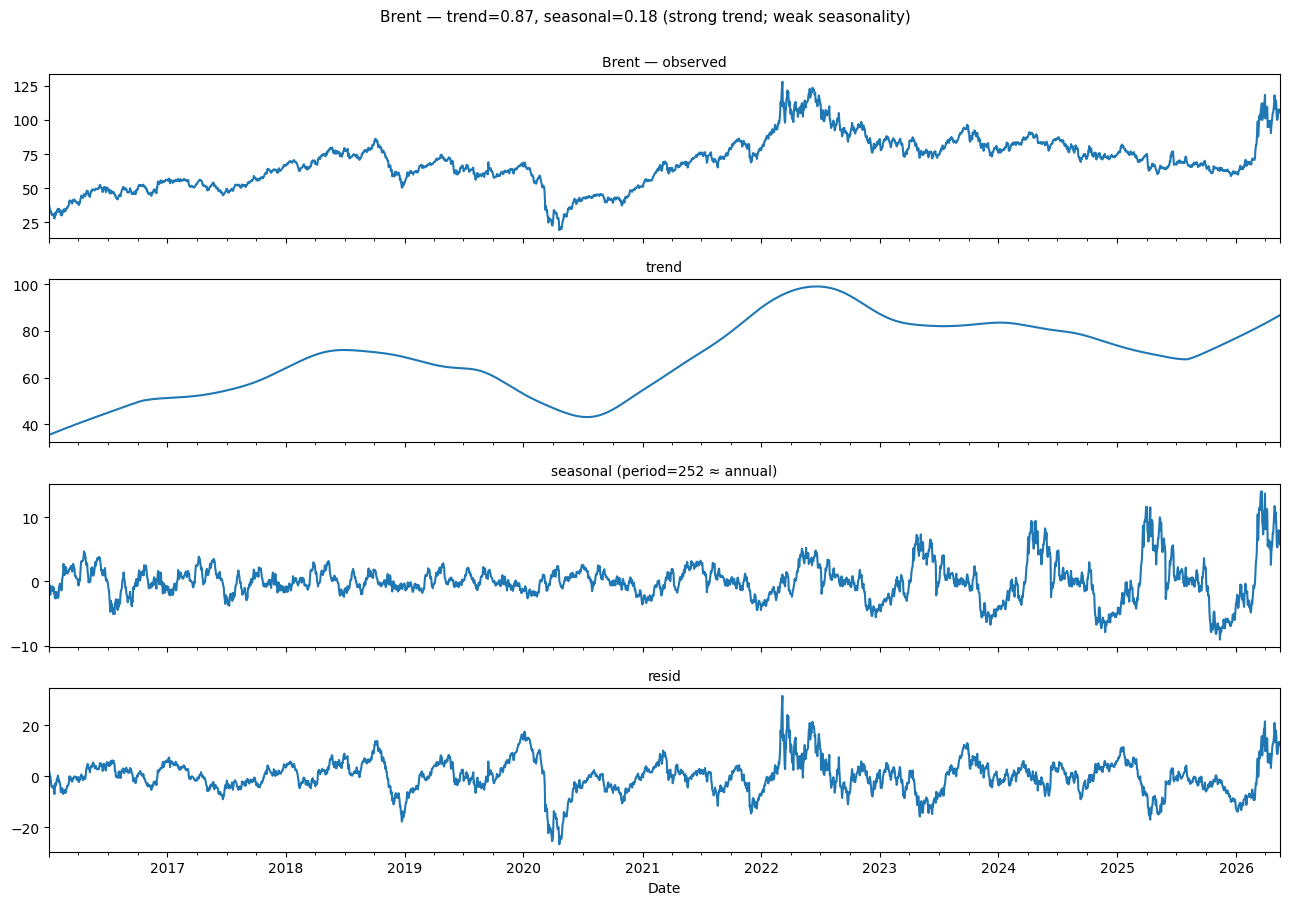

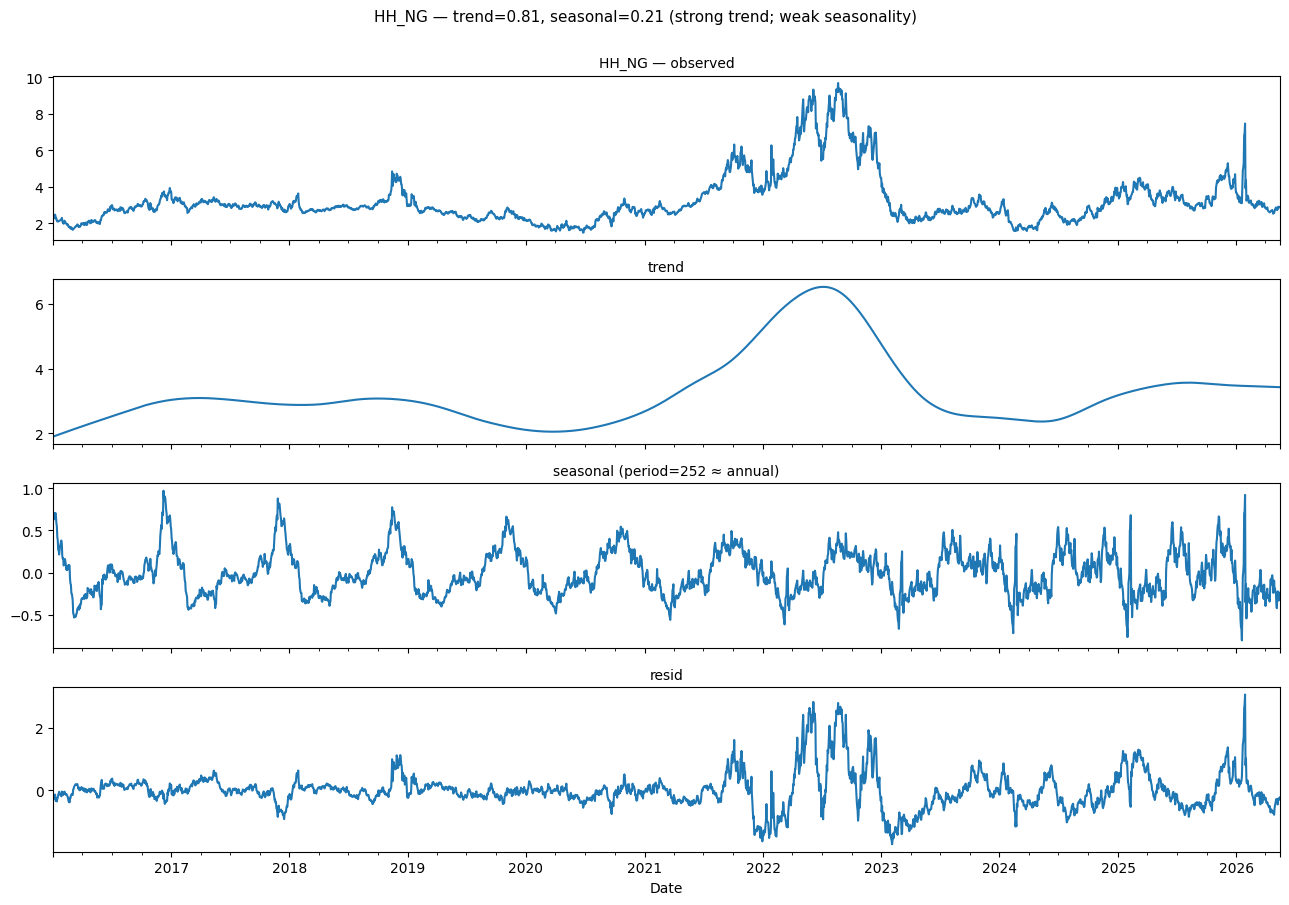

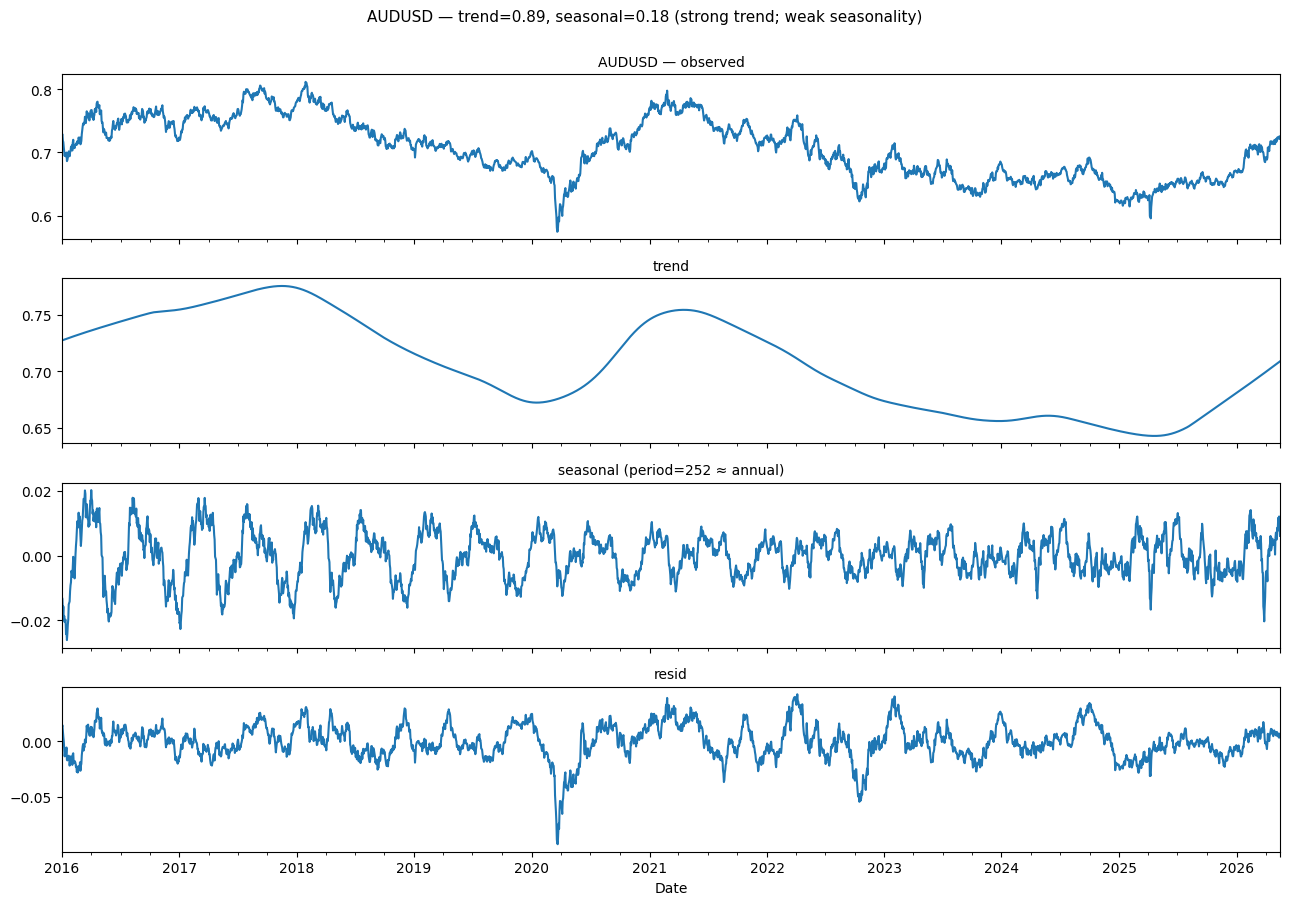


STL strength summary:
       trend_strength seasonal_strength                      conclusion
Brent        0.869214          0.176355  strong trend; weak seasonality
HH_NG        0.809474          0.207075  strong trend; weak seasonality
AUDUSD       0.891104          0.181168  strong trend; weak seasonality


In [27]:
# AUDUSD is intentionally included here as a NEGATIVE CONTROL —
# confirming it shows ~no seasonality is itself a finding (justifies
# different modelling treatment in Step 4 / Bucket 3).
pilots = ["Brent", "HH_NG", "AUDUSD"]
stl_results = {}

for col in pilots:
    s = prices[col].dropna()
    result = stl_decompose(s, name=col, period=252, seasonal=21)
    stl_results[col] = result
    comp = result["components"]

    fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)
    s.plot(ax=axes[0]);               axes[0].set_title(f"{col} — observed", fontsize=10)
    comp["trend"].plot(ax=axes[1]);   axes[1].set_title("trend", fontsize=10)
    comp["seasonal"].plot(ax=axes[2]);axes[2].set_title("seasonal (period=252 ≈ annual)", fontsize=10)
    comp["resid"].plot(ax=axes[3]);   axes[3].set_title("resid", fontsize=10)

    ts = result["statistic"]["trend_strength"]
    ss = result["statistic"]["seasonal_strength"]
    plt.suptitle(
        f"{col} — trend={ts:.2f}, seasonal={ss:.2f} ({result['conclusion']})",
        y=1.001, fontsize=11,
    )
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"step2_05_stl_{col}.png")
    plt.show()

print("\nSTL strength summary:")
print(pd.DataFrame({
    col: {
        "trend_strength":    r["statistic"]["trend_strength"],
        "seasonal_strength": r["statistic"]["seasonal_strength"],
        "conclusion":        r["conclusion"],
    }
    for col, r in stl_results.items()
}).T)

### ADF + KPSS on levels and returns for all 10 series. 

levels non-stationary, returns stationary → I(1) confirmed → modelling on returns or differenced levels is appropriate. Append to eda_test_results.csv.

### ARCH-LM test on returns at lags 5, 10. 

statistical confirmation of the squared-return ACF picture. This is the formal evidence motivating GARCH

In [28]:
test_rows = []

# ADF + KPSS on levels and returns
for col in TRADABLE:
    px = prices[col].dropna()
    rt = returns[col].dropna()
    test_rows.append(adf_test(px,  name=f"{col} (level)"))
    test_rows.append(kpss_test(px, name=f"{col} (level)"))
    test_rows.append(adf_test(rt,  name=f"{col} (return)"))
    test_rows.append(kpss_test(rt, name=f"{col} (return)"))

# ARCH-LM on returns at lags 5 and 10
for col in TRADABLE:
    rt = returns[col].dropna()
    for lag in (5, 10):
        test_rows.append(arch_lm_test(rt, name=f"{col} (return)", nlags=lag))

test_df = pd.DataFrame(test_rows)
test_df["step"] = "step2"

print(f"Total tests: {len(test_df)}\n")

print("ADF/KPSS on LEVELS (expect ADF p-high, KPSS p-low → non-stationary I(1)):")
m = test_df.series.str.contains(r"\(level\)")
print(test_df[m][["series", "test_name", "p_value", "conclusion"]].to_string(index=False))

print("\nADF/KPSS on RETURNS (expect ADF p-low, KPSS p-high → stationary):")
m = test_df.series.str.contains(r"\(return\)") & test_df.test_name.isin(["ADF", "KPSS(c)"])
print(test_df[m][["series", "test_name", "p_value", "conclusion"]].to_string(index=False))

print("\nARCH-LM (expect p-low → volatility clustering present):")
m = test_df.test_name.str.startswith("ARCH-LM")
print(test_df[m][["series", "test_name", "p_value", "conclusion"]].to_string(index=False))

# --- append to eda_test_results.csv (idempotent on re-run) ---
results_path = QUALITY_DIR / "eda_test_results.csv"
csv_df = test_df.copy()
for c in ("statistic", "critical_values"):
    csv_df[c] = csv_df[c].apply(lambda v: json.dumps(v) if isinstance(v, (dict, list)) else v)

if results_path.exists():
    existing = pd.read_csv(results_path)
    if "step" in existing.columns:
        existing = existing[existing["step"] != "step2"]
    csv_df = pd.concat([existing, csv_df], ignore_index=True)

csv_df.to_csv(results_path, index=False)
print(f"\nWrote {len(csv_df)} total rows to {results_path}")

Total tests: 60

ADF/KPSS on LEVELS (expect ADF p-high, KPSS p-low → non-stationary I(1)):
         series test_name  p_value     conclusion
  Brent (level)       ADF 0.184388 non-stationary
  Brent (level)   KPSS(c) 0.010000 non-stationary
    WTI (level)       ADF 0.172459 non-stationary
    WTI (level)   KPSS(c) 0.010000 non-stationary
     HO (level)       ADF 0.445663 non-stationary
     HO (level)   KPSS(c) 0.010000 non-stationary
   RBOB (level)       ADF 0.181248 non-stationary
   RBOB (level)   KPSS(c) 0.010000 non-stationary
  HH_NG (level)       ADF 0.025267     stationary
  HH_NG (level)   KPSS(c) 0.010000 non-stationary
    TTF (level)       ADF 0.128666 non-stationary
    TTF (level)   KPSS(c) 0.010000 non-stationary
    USO (level)       ADF 0.625432 non-stationary
    USO (level)   KPSS(c) 0.010000 non-stationary
    UNG (level)       ADF 0.546228 non-stationary
    UNG (level)   KPSS(c) 0.010000 non-stationary
    UGA (level)       ADF 0.994251 non-stationary
    UGA (

### Summary:

1. All 10 Bucket 1 series are I(1) in levels and stationary after converting to returns. `HH_NG` is the only exception where ADF and KPSS give different results. For modelling, we treat `HH_NG` as I(1) based on KPSS, and we recommend adding a structural-break dummy for the 2022 EU gas crisis.

2. Annual seasonality is mild across all three STL pilot checks based on the `F_S` metric, including `HH_NG`. However, the seasonal plots still suggest testing SARIMA for `HH_NG`, `TTF`, and `RBOB`, especially on pre-2021 sub-samples where the 2022 shock does not dominate the seasonal pattern.